# FastText

Importar embeddings preentrenados y reducir dimensionalidad:

In [1]:
import fasttext
import fasttext.util
import os

# Cargar modelo FastText pre-entrenado en español de Facebook (~7GB)
# Si no está descargado, descargar con: fasttext.util.download_model('es', if_exists='ignore')
if not os.path.exists('cc.es.300.bin'):
    print("Descargando cc.es.300.bin (~7GB)...")
    fasttext.util.download_model('es', if_exists='ignore')

ft = fasttext.load_model('cc.es.300.bin')
print(f"Dimensión del modelo cargado: {ft.get_dimension()}")
print(f"Tamaño del vocabulario: {len(ft.get_words()):,}")

# Reducir dimensionalidad de 300 a 100 (más manejable y rápido)
fasttext.util.reduce_model(ft, 100)
print(f"Dimensión después de reducir: {ft.get_dimension()}")

Dimensión del modelo cargado: 300
Tamaño del vocabulario: 2,000,000


/Users/davidzarruk/Documents/MIAD_ML_NLP_2026/.env/lib/python3.14/site-packages/fasttext/util/util.py:105: RuntimeWarning: divide by zero encountered in matmul
  C = np.divide(np.matmul(X.T, X), X.shape[0] - 1, dtype=np.float32)
/Users/davidzarruk/Documents/MIAD_ML_NLP_2026/.env/lib/python3.14/site-packages/fasttext/util/util.py:105: RuntimeWarning: overflow encountered in matmul
  C = np.divide(np.matmul(X.T, X), X.shape[0] - 1, dtype=np.float32)
/Users/davidzarruk/Documents/MIAD_ML_NLP_2026/.env/lib/python3.14/site-packages/fasttext/util/util.py:105: RuntimeWarning: invalid value encountered in matmul
  C = np.divide(np.matmul(X.T, X), X.shape[0] - 1, dtype=np.float32)
/Users/davidzarruk/Documents/MIAD_ML_NLP_2026/.env/lib/python3.14/site-packages/fasttext/util/util.py:109: RuntimeWarning: divide by zero encountered in matmul
  X_reduced = np.matmul(X_orig, eigv)
/Users/davidzarruk/Documents/MIAD_ML_NLP_2026/.env/lib/python3.14/site-packages/fasttext/util/util.py:109: RuntimeWarning:

Dimensión después de reducir: 100


Embeddings de algunas palabras:

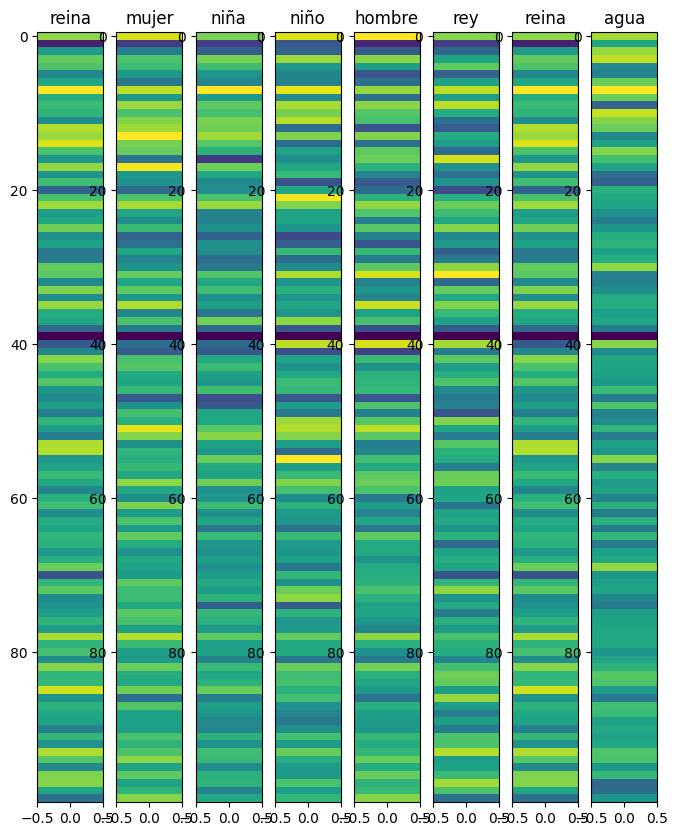

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Visualizar embeddings de algunas palabras
words = ['reina', 'mujer', 'niña', 'niño', 'hombre', 'rey', 'reina', 'agua']

D = ft.get_dimension()
fig, axs = plt.subplots(1, len(words), figsize=(len(words)*1, 10))

for i, word in enumerate(words):
    axs[i].imshow(ft.get_word_vector(word).reshape(D, 1), aspect='auto')
    axs[i].set_title(word)

plt.show()

In [3]:
# Palabras similares a 'rey'
word = 'rey'
neighbors = ft.get_nearest_neighbors(word, k=10)

print(f"Palabras similares a '{word}':")
for similarity, w in neighbors:
    print(f"  {w}: {similarity:.3f}")

Palabras similares a 'rey':
  emperador: 0.919
  príncipe: 0.860
  monarca: 0.857
  Emperador: 0.835
  sultán: 0.802
  Rey: 0.789
  califa: 0.778
  vasallo: 0.778
  emir: 0.774
  caballero: 0.770


In [4]:
# Analogía: 'rey' - 'hombre' + 'mujer' = ?
# get_analogies(A, B, C) computa: A - B + C
print("rey - hombre + mujer = ?")
for similarity, w in ft.get_analogies('rey', 'hombre', 'mujer', k=10):
    print(f"  {w}: {similarity:.3f}")

rey - hombre + mujer = ?
  emperatriz: 0.812
  reina: 0.802
  princesa: 0.788
  emperadora: 0.743
  Emperatriz: 0.721
  infanta: 0.706
  dama: 0.700
  Reina: 0.700
  Emperadora: 0.695
  emperatríz: 0.694


In [5]:
# Palabras similares a 'messi'
word = 'messi'
neighbors = ft.get_nearest_neighbors(word, k=10)

print(f"Palabras similares a '{word}':")
for similarity, w in neighbors:
    print(f"  {w}: {similarity:.3f}")

Palabras similares a 'messi':
  ronaldo: 0.878
  neymar: 0.859
  maradona: 0.843
  ronaldinho: 0.843
  zidane: 0.820
  higuain: 0.818
  mourinho: 0.802
  tevez: 0.798
  barsa: 0.796
  benzema: 0.795


In [6]:
# Analogía: messi - futbol + boxeo  →  el "messi del boxeo"
print("messi - futbol + boxeo = ?")
for similarity, w in ft.get_analogies('messi', 'futbol', 'boxeo', k=10):
    print(f"  {w}: {similarity:.3f}")

messi - futbol + boxeo = ?
  maidana: 0.734
  maradona: 0.720
  pacquiao: 0.715
  mayweather: 0.710
  maywether: 0.706
  ronaldinho: 0.698
  matthysse: 0.696
  ronaldo: 0.691
  neymar: 0.690
  weidman: 0.687


In [7]:
# Analogía: messi - barcelona + madrid  →  jugadores asociados a Madrid
print("messi - barcelona + madrid = ?")
for similarity, w in ft.get_analogies('messi', 'barcelona', 'madrid', k=20):
    print(f"  {w}: {similarity:.3f}")

messi - barcelona + madrid = ?
  barsa: 0.837
  ronaldo: 0.814
  mourinho: 0.799
  neymar: 0.798
  maradona: 0.787
  higuain: 0.785
  simeone: 0.784
  benzema: 0.779
  ronaldinho: 0.773
  barza: 0.767
  iniesta: 0.764
  barça: 0.762
  bielsa: 0.762
  zidane: 0.756
  robinho: 0.751
  ronaldiño: 0.750
  trezeguet: 0.749
  ibrahimovic: 0.749
  modric: 0.748
  robben: 0.744


In [10]:
# Analogía: fútbol - pies + manos  →  baloncesto, basketball?
print("fútbol - pies + manos = ?")
for similarity, w in ft.get_analogies('fútbol', 'pies', 'manos', k=20):
    print(f"  {w}: {similarity:.3f}")

fútbol - pies + manos = ?
  futbolísticas: 0.689
  futboleras: 0.653
  ligas: 0.651
  balompié: 0.645
  futbolístico: 0.641
  selecciones: 0.640
  partido: 0.631
  futbol: 0.614
  eliminatorias: 0.613
  antifútbol: 0.611
  básquet: 0.611
  futsal: 0.610
  rugbístico: 0.606
  anti-fútbol: 0.605
  fúltbol: 0.601
  Ponyfútbol: 0.600
  futbolísta: 0.599
  Difútbol: 0.598
  quinielas: 0.597
  baloncesto: 0.592
